In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(stringr)
library(scRepertoire)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [2]:
pep_rich <- readRDS('vst3_with_tcr.rds')

In [3]:
pep_rich <- subset(pep_rich, pep_enriched == 'Pep-Enriched')

In [4]:
pep_rich$Stemness_Concentration <- paste(pep_rich$Stemness,pep_rich$Concentration, sep='_')

In [5]:
table(pep_rich$Stemness_Concentration)


       DMSO_NA          NA_NA  TWS-119_10_uM   TWS-119_1_uM   TWS-119_5_uM 
         23713          51089            563           7212             49 
UK5099_12.5_uM   UK5099_25_uM   UK5099_50_uM 
         10364           9898          15362 

In [6]:
pep_rich <- subset(pep_rich, Stemness_Concentration %in% c('TWS-119_5_uM','TWS-119_10_uM'), invert = T)

In [7]:
table(pep_rich$Peptide)


   Pep+ Pep_neg 
 114208    3394 

In [8]:
pep_rich <- subset(pep_rich, Peptide == 'Pep+')

Warning message:
“Removing 36 cells missing data for vars requested”


In [9]:
pep_rich <- JoinLayers(pep_rich)

In [10]:
library(harmony)

Loading required package: Rcpp

Warning message:
“package ‘Rcpp’ was built under R version 4.4.3”


In [11]:
pep_rich <- NormalizeData(pep_rich) %>% FindVariableFeatures() %>% ScaleData()

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”


In [12]:
s.genes <- cc.genes$s.genes
g2m.genes <- cc.genes$g2m.genes

In [13]:
pep_rich <- CellCycleScoring(pep_rich, s.features = s.genes, g2m.features = g2m.genes, set.ident = TRUE)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The following features are not present in the object: MLF1IP, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: FAM64A, HN1, not searching for symbol synonyms”


In [14]:
pep_rich <- ScaleData(pep_rich, vars.to.regress = c("S.Score","G2M.Score"), features = VariableFeatures(pep_rich))

Regressing out S.Score, G2M.Score

Centering and scaling data matrix



In [15]:
pep_rich <- RunPCA(pep_rich, features = VariableFeatures(pep_rich)) %>% RunHarmony("Donor") %>% 
    RunUMAP(reduction = 'harmony', dims=1:25)

PC_ 1 
Positive:  CCL4, TNFAIP3, KDM5D, UTY, HAVCR2, KLRG1, FGL2, LILRB1, DDX3Y, IFI44 
	   IFI44L, MT-ND3, EIF1AY, AK1, LINC02694, GNLY, ARL6IP1, PATL2, PRDM1, GPR141 
	   CSGALNACT1, SYCP2, ARHGAP11B, CX3CR1, PLEKHA5, PDCD1, NTNG2, FCGR3A, KLRB1, PLXND1 
Negative:  LDHB, EBP, HSP90AB1, ENO1, OAZ1, FTL, FASN, PKM, ACTG1, UBA52 
	   S100A10, SCD, ACAT2, ARHGDIB, NME2, H2AZ1, SRI, SNX10, TMSB10, YWHAQ 
	   SET, EIF4A1, TUBA1B, RACK1, COTL1, LMNB1, ATP5MC3, DDX21, DPP4, PRDX1 
PC_ 2 
Positive:  MT-ND3, MT-ND2, MT-CYB, MT-ATP6, MT-ND4, MT-CO2, MT-ND4L, MT-ND5, MT-CO3, MT-ND1 
	   MT-CO1, EIF1AY, S1PR1, CCND2, DDX3Y, GPR183, KDM5D, KLF2, ITGA4, VIM 
	   UTY, ARL4C, MT-ND6, FGL2, CCR4, MYB, ANXA2, PRDM1, RASGRP2, GNLY 
Negative:  KLRC4, PIK3AP1, SCD, AIF1, CD300A, SERPINB9, XCL2, HMGCS1, SREBF1, CD160 
	   IDH2, FADS2, HOPX, CYRIA, GZMM, GZMK, TFEC, FADS1, CLU, CD27 
	   FLT4, SREBF2, MGAT1, ITGAX, EOMES, PTPN20, H2BC9, RNF138, LSS, TESC 
PC_ 3 
Positive:  H2BC9, H1-5, H4C3, H1-2, H1-4, RRM

In [16]:
pep_rich <- FindNeighbors(pep_rich, dims=1:25, reduction='harmony') %>% FindClusters(repep_richlution = 0.5)

Computing nearest neighbor graph

Warning message:
“package ‘future’ was built under R version 4.4.3”
Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 114208
Number of edges: 2288891

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8237
Number of communities: 14
Elapsed time: 51 seconds


4 singletons identified. 10 final clusters.



In [21]:
pep_rich <- FindClusters(pep_rich, repep_richlution = 0.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 114208
Number of edges: 2288891

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8237
Number of communities: 14
Elapsed time: 54 seconds


4 singletons identified. 10 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



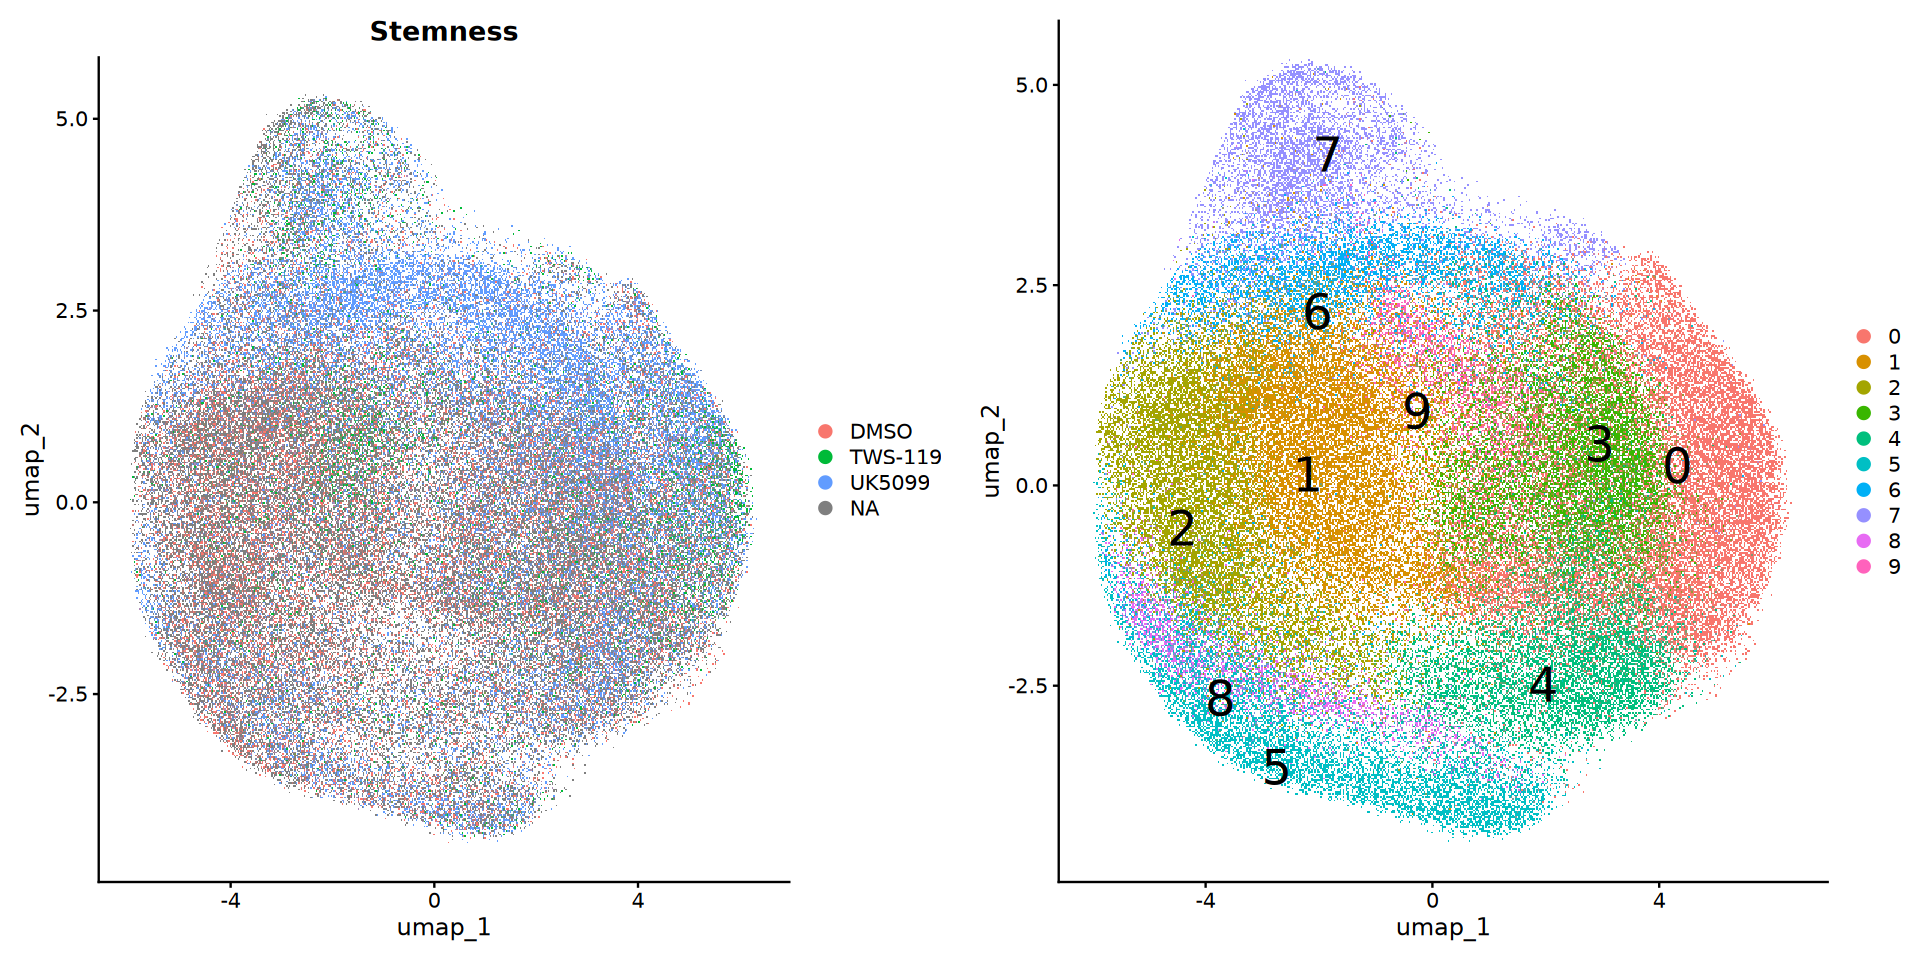

In [91]:
options(repr.plot.width = 16, repr.plot.height = 8)
p1 <- DimPlot(pep_rich, group.by = 'Stemness')
p2 <- DimPlot(pep_rich, label=T, label.size = 10, repel = T)
plot_grid(p1,p2,ncol=2)

In [203]:
# Open the PDF graphics device
pdf("plots/Fig2g_cluster_umap.pdf", width = 8, height = 8) # You can specify width and height in inches

# Create your plot
DimPlot(pep_rich, label=T, label.size = 10, repel = T, raster = F)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [109]:
saveRDS(pep_rich, 'pep_rich_cluster.rds')